## 1. Install Dependencies

In [ ]:
!pip install nibabel tqdm scikit-learn matplotlib

## 2. Imports

In [ ]:
import os
import numpy as np
import nibabel as nib
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

## 3. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4. Dataset Path

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Task02_Heart/Task02_Heart"

IMG_DIR = os.path.join(DATASET_PATH, "imagesTr")
MASK_DIR = os.path.join(DATASET_PATH, "labelsTr")

print("Images:", len(os.listdir(IMG_DIR)))
print("Masks:",  len(os.listdir(MASK_DIR)))

Images: 21
Masks: 22


## 5. Preprocessing Helpers

In [ ]:
IMG_SIZE = 256

def normalize_image(img):
    img = img.astype(np.float32)
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)
    return img

def resize_slice(slice_img):
    slice_img = tf.image.resize(slice_img[..., np.newaxis], (IMG_SIZE, IMG_SIZE))
    return slice_img.numpy()

## 6. Load .nii.gz Data

In [ ]:
X, Y = [], []
files = sorted(os.listdir(IMG_DIR))
print("Loading dataset...")

for f in tqdm(files):
    if f.startswith('._'):
        continue
    img_path  = os.path.join(IMG_DIR,  f)
    mask_path = os.path.join(MASK_DIR, f)
    img  = nib.load(img_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    for i in range(img.shape[2]):
        img_slice  = normalize_image(img[:, :, i])
        mask_slice = mask[:, :, i]

        img_slice  = resize_slice(img_slice)[:, :, 0]
        mask_slice = resize_slice(mask_slice)[:, :, 0]
        mask_slice = (mask_slice > 0).astype(np.float32)

        X.append(img_slice)
        Y.append(mask_slice)

X = np.expand_dims(np.array(X), axis=-1)
Y = np.expand_dims(np.array(Y), axis=-1)
print("X shape:", X.shape)
print("Y shape:", Y.shape)

Loading dataset...


100%|██████████| 21/21 [00:47<00:00,  2.24s/it]


X shape: (2271, 256, 256, 1)
Y shape: (2271, 256, 256, 1)


## 7. Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (1816, 256, 256, 1)
Test:  (455, 256, 256, 1)


## 8. Shared Loss Functions & Metrics

In [ ]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def compute_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred)
    union        = np.logical_or(y_true,  y_pred)
    union_sum    = np.sum(union)
    return 1.0 if union_sum == 0 else np.sum(intersection) / union_sum

def evaluate_model(model, X_test, y_test, threshold=0.3):
    """Returns dict with dice, iou, accuracy, precision, recall, f1"""
    preds = model.predict(X_test, verbose=0)
    preds_bin = (preds > threshold).astype(np.uint8)

    # Per-image Dice
    dice_scores = []
    iou_scores  = []
    for i in range(len(X_test)):
        yt = y_test[i].flatten()
        yp = preds_bin[i].flatten()
        inter = np.sum(yt * yp)
        denom = np.sum(yt) + np.sum(yp)
        dice_scores.append((2 * inter) / (denom + 1e-8) if denom > 0 else 1.0)
        iou_scores.append(compute_iou(y_test[i], preds_bin[i]))

    # Global pixel-level metrics from confusion matrix
    yt_flat = y_test.flatten()
    yp_flat = preds_bin.flatten()
    cm = confusion_matrix(yt_flat, yp_flat)
    tn, fp, fn, tp = cm.ravel()

    accuracy  = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    results = {
        "dice":      np.mean(dice_scores),
        "iou":       np.mean(iou_scores),
        "accuracy":  accuracy,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "cm":        cm
    }
    return results, preds_bin

---
## 9. Model 1 — U-Net (Original)


In [ ]:
def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(32,  3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32,  3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64,  3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64,  3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(b)

    # Decoder
    u1 = layers.UpSampling2D()(b);  u1 = layers.concatenate([u1, c3])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c4); u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(64,  3, activation='relu', padding='same')(u2)

    u3 = layers.UpSampling2D()(c5); u3 = layers.concatenate([u3, c1])
    c6 = layers.Conv2D(32,  3, activation='relu', padding='same')(u3)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)
    return models.Model(inputs, outputs, name='UNet')

unet_model = build_unet()
unet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                   loss=bce_dice_loss, metrics=[dice_coef])
unet_model.summary()

Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[

 Total params: 1,752,545 (6.69 MB)

 Trainable params: 1,752,545 (6.69 MB)

 Non-trainable params: 0 (0.00 B)

### Train U-Net

In [ ]:
unet_history = unet_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 71s 229ms/step - dice_coef: 0.2305 - loss: 0.8560 - val_dice_coef: 0.4934 - val_loss: 0.5408
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 111ms/step - dice_coef: 0.5179 - loss: 0.5066 - val_dice_coef: 0.6325 - val_loss: 0.3810
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - dice_coef: 0.6111 - loss: 0.4049 - val_dice_coef: 0.6894 - val_loss: 0.3216
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 24s 118ms/step - dice_coef: 0.7005 - loss: 0.3114 - val_dice_coef: 0.7943 - val_loss: 0.2114
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - dice_coef: 0.7711 - loss: 0.2377 - val_dice_coef: 0.8049 - val_loss: 0.2019
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - dice_coef: 0.8225 - loss: 0.1842 - val_dice_coef: 0.8541 - val_loss: 0.1499
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 24s 117ms/step - dice_coef: 0.8561 - loss: 0.1486 - val_dice_coef: 0.8482 - val_loss: 0.1556
Epoch 8/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 24s 117ms/step - dice_coef: 0

### Evaluate U-Net

=== U-Net Results ===
  dice      : 0.9080
  iou       : 0.8744
  accuracy  : 0.9996
  precision : 0.9523
  recall    : 0.9475
  f1        : 0.9499


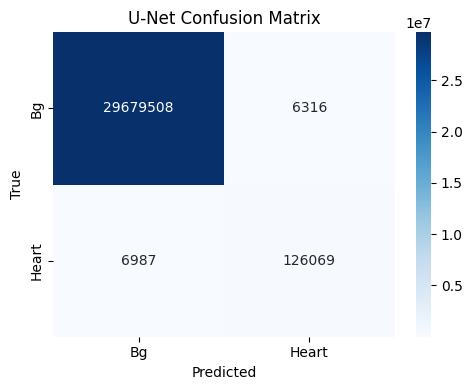

In [ ]:
unet_results, unet_preds = evaluate_model(unet_model, X_test, y_test)
print("=== U-Net Results ===")
for k, v in unet_results.items():
    if k != 'cm':
        print(f"  {k:10s}: {v:.4f}")

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(unet_results['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bg','Heart'], yticklabels=['Bg','Heart'])
plt.title('U-Net Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Visualise U-Net Predictions

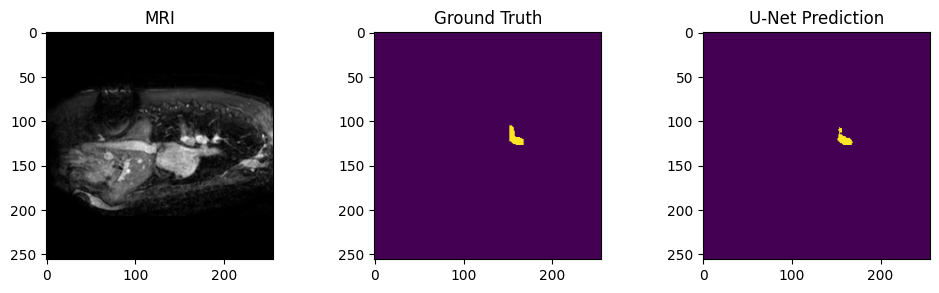

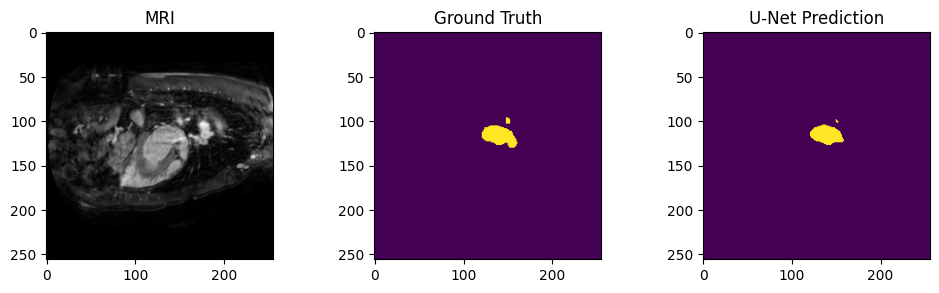

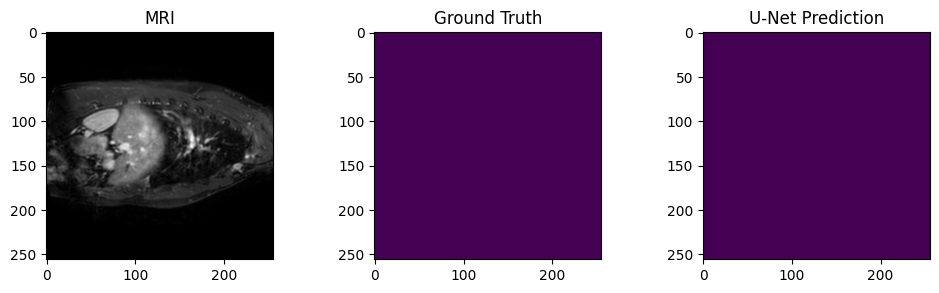

In [ ]:
for i in range(3):
    idx = np.random.randint(0, len(X_test))
    plt.figure(figsize=(10, 3))
    plt.subplot(1,3,1); plt.imshow(X_test[idx].squeeze(), cmap='gray');   plt.title('MRI')
    plt.subplot(1,3,2); plt.imshow(y_test[idx].squeeze());                plt.title('Ground Truth')
    plt.subplot(1,3,3); plt.imshow(unet_preds[idx].squeeze());            plt.title('U-Net Prediction')
    plt.tight_layout(); plt.show()

In [ ]:
import numpy as np

# Select a random index for demonstration, similar to visualization cells
idx = np.random.randint(0, len(X_test))

y_true = y_test[idx]
y_pred = unet_preds[idx] # Corrected: Use unet_preds for the predicted mask

# Ensure y_pred is binary, as dice_coef expects binary masks for accurate calculation
y_pred_binary = (y_pred > 0.5).astype(np.float32) # Assuming a threshold of 0.5 for binarization

intersection = np.sum(y_true * y_pred_binary)
dice = (2. * intersection) / (np.sum(y_true) + np.sum(y_pred_binary) + 1e-8) # Added epsilon for stability

print(f"Dice score for image at index {idx}: {dice:.4f}")

Dice score for image at index 3: 0.9172


---
## 10. Model 2 — ResNet-UNet


In [ ]:
def resnet_block(x, filters):
    """A residual block: two conv layers + identity shortcut."""
    shortcut = layers.Conv2D(filters, 1, padding='same')(x)  # match channels
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnet_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # Encoder with residual blocks
    c1 = resnet_block(inputs, 32);  p1 = layers.MaxPooling2D()(c1)
    c2 = resnet_block(p1,     64);  p2 = layers.MaxPooling2D()(c2)
    c3 = resnet_block(p2,    128);  p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    b = resnet_block(p3, 256)

    # Decoder
    u1 = layers.UpSampling2D()(b);  u1 = layers.concatenate([u1, c3])
    d1 = resnet_block(u1, 128)

    u2 = layers.UpSampling2D()(d1); u2 = layers.concatenate([u2, c2])
    d2 = resnet_block(u2, 64)

    u3 = layers.UpSampling2D()(d2); u3 = layers.concatenate([u3, c1])
    d3 = resnet_block(u3, 32)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d3)
    return models.Model(inputs, outputs, name='ResNet_UNet')

resnet_model = build_resnet_unet()
resnet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss=bce_dice_loss, metrics=[dice_coef])
resnet_model.summary()

Model: "ResNet_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 256, 256,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 256, 256,  │         64 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 128, 128,  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │      2,112 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ add_1[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ activation_1[0][

 Total params: 2,060,193 (7.86 MB)

 Trainable params: 2,057,377 (7.85 MB)

 Non-trainable params: 2,816 (11.00 KB)

### Train ResNet-UNet

In [ ]:
resnet_history = resnet_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 76s 256ms/step - dice_coef: 0.6540 - loss: 0.3767 - val_dice_coef: 0.0018 - val_loss: 1.0302
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 179ms/step - dice_coef: 0.8444 - loss: 0.1628 - val_dice_coef: 6.5731e-04 - val_loss: 1.0418
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 179ms/step - dice_coef: 0.8838 - loss: 0.1212 - val_dice_coef: 0.6635 - val_loss: 0.3466
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 179ms/step - dice_coef: 0.8982 - loss: 0.1066 - val_dice_coef: 0.8573 - val_loss: 0.1475
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 179ms/step - dice_coef: 0.9120 - loss: 0.0885 - val_dice_coef: 0.9074 - val_loss: 0.0954
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 179ms/step - dice_coef: 0.9264 - loss: 0.0770 - val_dice_coef: 0.9006 - val_loss: 0.1034
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 178ms/step - dice_coef: 0.9352 - loss: 0.0676 - val_dice_coef: 0.9231 - val_loss: 0.0800
Epoch 8/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 178ms/step - dice_coe

### Evaluate ResNet-UNet

=== ResNet-UNet Results ===
  dice      : 0.8839
  iou       : 0.8466
  accuracy  : 0.9994
  precision : 0.9395
  recall    : 0.9176
  f1        : 0.9284


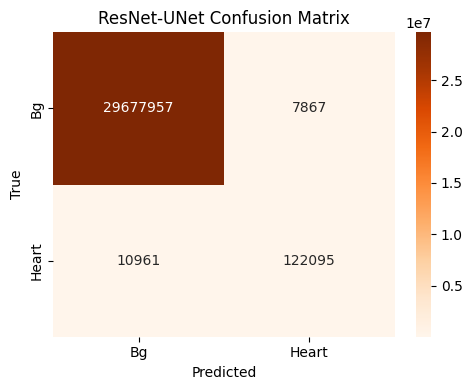

In [ ]:
resnet_results, resnet_preds = evaluate_model(resnet_model, X_test, y_test)
print("=== ResNet-UNet Results ===")
for k, v in resnet_results.items():
    if k != 'cm':
        print(f"  {k:10s}: {v:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(resnet_results['cm'], annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bg','Heart'], yticklabels=['Bg','Heart'])
plt.title('ResNet-UNet Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Visualise ResNet-UNet Predictions

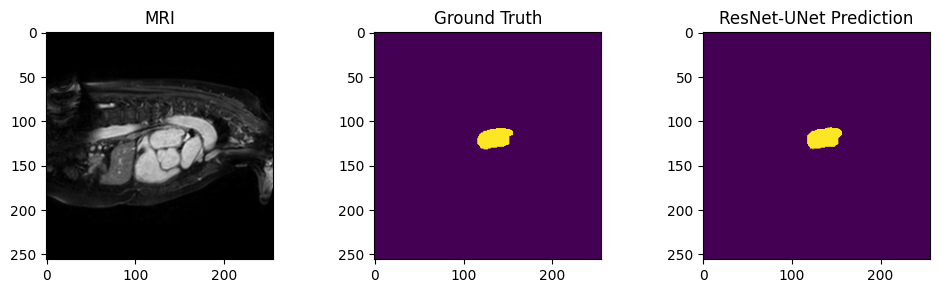

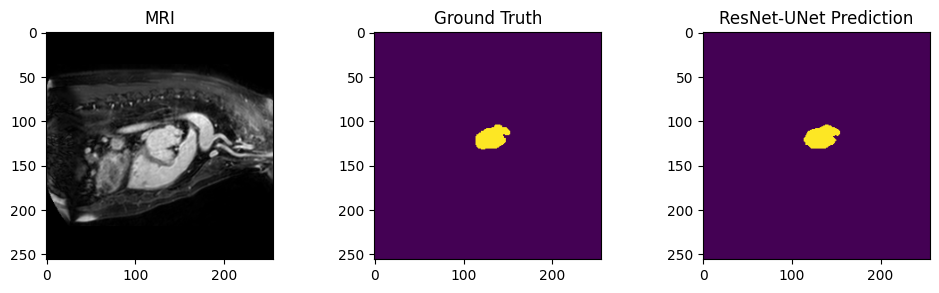

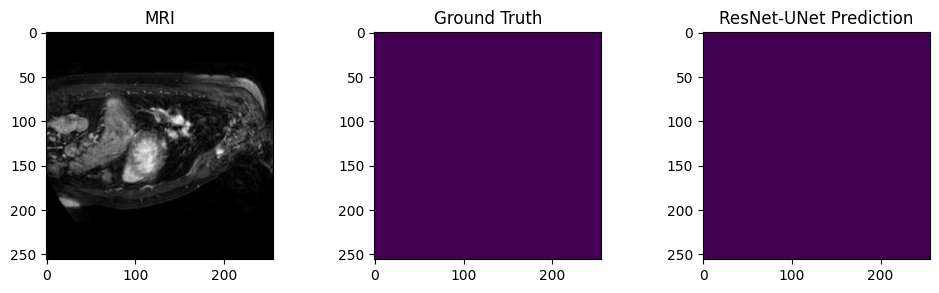

In [ ]:
for i in range(3):
    idx = np.random.randint(0, len(X_test))
    plt.figure(figsize=(10, 3))
    plt.subplot(1,3,1); plt.imshow(X_test[idx].squeeze(), cmap='gray');    plt.title('MRI')
    plt.subplot(1,3,2); plt.imshow(y_test[idx].squeeze());                 plt.title('Ground Truth')
    plt.subplot(1,3,3); plt.imshow(resnet_preds[idx].squeeze());           plt.title('ResNet-UNet Prediction')
    plt.tight_layout(); plt.show()

In [ ]:
import numpy as np

# Select a random index for demonstration, similar to visualization cells
idx = np.random.randint(0, len(X_test))

y_true = y_test[idx]
y_pred = resnet_preds[idx] # Corrected: Use resnet_preds for the predicted mask

# Ensure y_pred is binary, as dice_coef expects binary masks for accurate calculation
y_pred_binary = (y_pred > 0.5).astype(np.float32) # Assuming a threshold of 0.5 for binarization

intersection = np.sum(y_true * y_pred_binary)
dice = (2. * intersection) / (np.sum(y_true) + np.sum(y_pred_binary) + 1e-8) # Added epsilon for stability

print(f"Dice score for image at index {idx}: {dice:.4f}")

Dice score for image at index 428: 0.9383


---
## 11. Model 3 — SegNet


In [ ]:
def conv_bn_relu(x, filters, n=2):
    """n consecutive Conv → BN → ReLU layers."""
    for _ in range(n):
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
    return x

def build_segnet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # ── Encoder ──────────────────────────────────────────────────────────────
    e1 = conv_bn_relu(inputs, 64, 2);  p1 = layers.MaxPooling2D()(e1)
    e2 = conv_bn_relu(p1,     128, 2); p2 = layers.MaxPooling2D()(e2)
    e3 = conv_bn_relu(p2,     256, 3); p3 = layers.MaxPooling2D()(e3)
    e4 = conv_bn_relu(p3,     512, 3); p4 = layers.MaxPooling2D()(e4)

    # ── Decoder (UpSampling2D approximates max-pooling unpooling) ────────────
    d4 = layers.UpSampling2D()(p4); d4 = conv_bn_relu(d4, 512, 3)
    d3 = layers.UpSampling2D()(d4); d3 = conv_bn_relu(d3, 256, 3)
    d2 = layers.UpSampling2D()(d3); d2 = conv_bn_relu(d2, 128, 2)
    d1 = layers.UpSampling2D()(d2); d1 = conv_bn_relu(d1,  64, 2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d1)
    return models.Model(inputs, outputs, name='SegNet')

segnet_model = build_segnet()
segnet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss=bce_dice_loss, metrics=[dice_coef])
segnet_model.summary()

Model: "SegNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 64, 64, 256)    │       590,08

 Total params: 17,648,513 (67.32 MB)

 Trainable params: 17,637,761 (67.28 MB)

 Non-trainable params: 10,752 (42.00 KB)

### Train SegNet

In [ ]:
segnet_history = segnet_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 195s 698ms/step - dice_coef: 0.0587 - loss: 1.1007 - val_dice_coef: 0.0097 - val_loss: 2.6093
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 102s 497ms/step - dice_coef: 0.0971 - loss: 0.9855 - val_dice_coef: 0.0084 - val_loss: 1.0657
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 102s 495ms/step - dice_coef: 0.1453 - loss: 0.9105 - val_dice_coef: 0.1092 - val_loss: 0.9407
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 102s 495ms/step - dice_coef: 0.2192 - loss: 0.8158 - val_dice_coef: 0.2647 - val_loss: 0.7588
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 102s 496ms/step - dice_coef: 0.3363 - loss: 0.6854 - val_dice_coef: 0.3394 - val_loss: 0.7162
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 102s 496ms/step - dice_coef: 0.4649 - loss: 0.5478 - val_dice_coef: 0.4463 - val_loss: 0.5647
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 101s 495ms/step - dice_coef: 0.6003 - loss: 0.4093 - val_dice_coef: 0.6761 - val_loss: 0.3290
Epoch 8/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 102s 496ms/step - dice

### Evaluate SegNet

=== SegNet Results ===
  dice      : 0.9258
  iou       : 0.8906
  accuracy  : 0.9995
  precision : 0.9535
  recall    : 0.9405
  f1        : 0.9470


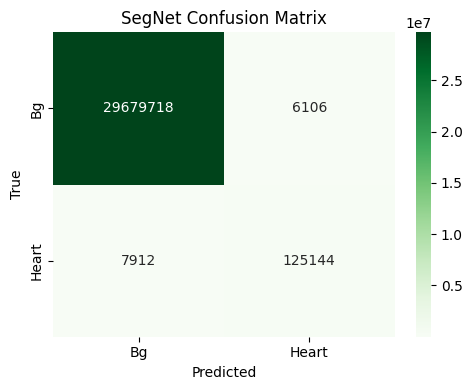

In [ ]:
segnet_results, segnet_preds = evaluate_model(segnet_model, X_test, y_test)
print("=== SegNet Results ===")
for k, v in segnet_results.items():
    if k != 'cm':
        print(f"  {k:10s}: {v:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(segnet_results['cm'], annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bg','Heart'], yticklabels=['Bg','Heart'])
plt.title('SegNet Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Visualise SegNet Predictions

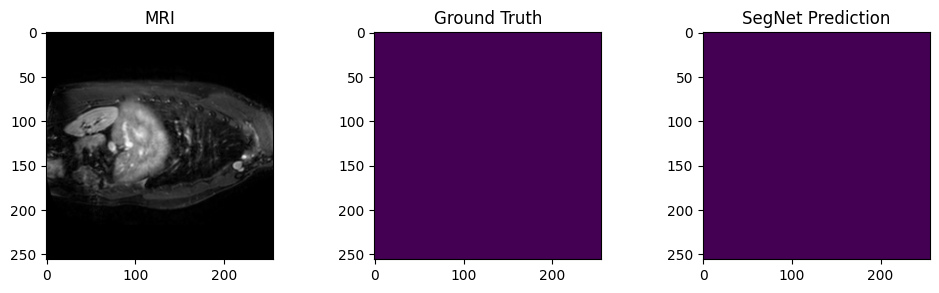

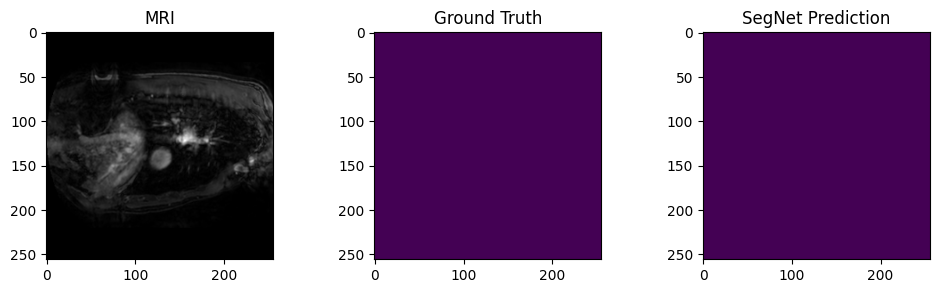

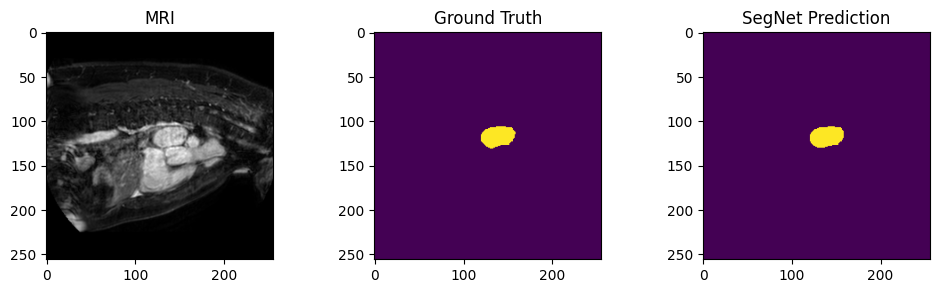

In [ ]:
for i in range(3):
    idx = np.random.randint(0, len(X_test))
    plt.figure(figsize=(10, 3))
    plt.subplot(1,3,1); plt.imshow(X_test[idx].squeeze(), cmap='gray');  plt.title('MRI')
    plt.subplot(1,3,2); plt.imshow(y_test[idx].squeeze());               plt.title('Ground Truth')
    plt.subplot(1,3,3); plt.imshow(segnet_preds[idx].squeeze());         plt.title('SegNet Prediction')
    plt.tight_layout(); plt.show()

In [ ]:
import numpy as np

# Select a random index for demonstration, similar to visualization cells
idx = np.random.randint(0, len(X_test))

y_true = y_test[idx]
y_pred = segnet_preds[idx] # Corrected: Use segnet_preds for the predicted mask

# Ensure y_pred is binary, as dice_coef expects binary masks for accurate calculation
y_pred_binary = (y_pred > 0.5).astype(np.float32) # Assuming a threshold of 0.5 for binarization

intersection = np.sum(y_true * y_pred_binary)
dice = (2. * intersection) / (np.sum(y_true) + np.sum(y_pred_binary) + 1e-8) # Added epsilon for stability

print(f"Dice score for image at index {idx}: {dice:.4f}")

Dice score for image at index 8: 0.9726


---
## 12. Model 4 — DeepLabV3+


In [ ]:
def aspp_block(x, filters=256):
    """Atrous Spatial Pyramid Pooling block — captures context at multiple scales."""
    # Global average pooling branch
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Reshape((1, 1, gap.shape[-1]))(gap)
    gap = layers.Conv2D(filters, 1, padding='same', activation='relu')(gap)
    gap = layers.UpSampling2D(size=(x.shape[1], x.shape[2]), interpolation='bilinear')(gap)

    # Atrous convolutions at different rates
    a1 = layers.Conv2D(filters, 1, dilation_rate=1,  padding='same', activation='relu')(x)
    a6 = layers.Conv2D(filters, 3, dilation_rate=6,  padding='same', activation='relu')(x)
    a12= layers.Conv2D(filters, 3, dilation_rate=12, padding='same', activation='relu')(x)
    a18= layers.Conv2D(filters, 3, dilation_rate=18, padding='same', activation='relu')(x)

    out = layers.concatenate([gap, a1, a6, a12, a18])
    out = layers.Conv2D(filters, 1, activation='relu')(out)
    out = layers.BatchNormalization()(out)
    return out

def build_deeplabv3plus(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # ── Encoder (light-weight backbone with stride-8) ─────────────────
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)  # 128
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)       # 64
    x = layers.BatchNormalization()(x)

    # Low-level features saved for decoder
    low_level = layers.Conv2D(48, 1, activation='relu')(x)

    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)      # 32
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # ── ASPP ──────────────────────────────────────────────────────────
    x = aspp_block(x, filters=256)

    # ── Decoder ──────────────────────────────────────────────────────────
    x = layers.UpSampling2D(size=(4, 4), interpolation='bilinear')(x)   # 32 -> 128
    x = layers.Conv2D(256, 1, activation='relu')(x)

    # Upsample low_level to match x's spatial dimensions (128x128)
    upsampled_low_level = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(low_level)
    x = layers.concatenate([x, upsampled_low_level])
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Upsample back to original resolution
    x = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(x)   # 128 -> 256 (Corrected from 4,4)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)

    return models.Model(inputs, outputs, name='DeepLabV3Plus')

deeplabv3_model = build_deeplabv3plus()
deeplabv3_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                        loss=bce_dice_loss, metrics=[dice_coef])
deeplabv3_model.summary()

Model: "DeepLabV3Plus"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (None, 128, 128,  │        320 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_82[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_83 (Conv2D)  │ (None, 64, 64,    │     18,496 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_83[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_85 (Conv2D)  │ (None, 32, 32,    │     73,856 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_85[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_86 (Conv2D)  │ (None, 32, 32,    │    295,168 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_86[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1, 256) │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_87 (Conv2D)  │ (None, 1, 1, 256) │     65,792 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_16    │ (None, 32, 32,    │          0 │ conv2d_87[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_88 (Conv2D)  │ (None, 32, 32,    │     65,792 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_89 (Conv2D)  │ (None, 32, 32,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_90 (Conv2D)  │ (None, 32, 32,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_91 (Conv2D)  │ (None, 32, 32,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,982,513 (15.19 MB)

 Trainable params: 3,980,017 (15.18 MB)

 Non-trainable params: 2,496 (9.75 KB)

### Train DeepLabV3+

In [ ]:
deeplabv3_history = deeplabv3_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 168s 614ms/step - dice_coef: 0.0205 - loss: 1.5335 - val_dice_coef: 0.0086 - val_loss: 1.2888
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 90s 440ms/step - dice_coef: 0.0332 - loss: 1.2784 - val_dice_coef: 0.0276 - val_loss: 1.1123
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 90s 439ms/step - dice_coef: 0.0580 - loss: 1.1130 - val_dice_coef: 0.0769 - val_loss: 1.0514
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 90s 438ms/step - dice_coef: 0.1046 - loss: 0.9936 - val_dice_coef: 0.2029 - val_loss: 0.8425
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 90s 437ms/step - dice_coef: 0.2252 - loss: 0.8326 - val_dice_coef: 0.4820 - val_loss: 0.5310
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 90s 437ms/step - dice_coef: 0.5197 - loss: 0.5045 - val_dice_coef: 0.7598 - val_loss: 0.2812
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 89s 436ms/step - dice_coef: 0.7703 - loss: 0.2441 - val_dice_coef: 0.8695 - val_loss: 0.1394
Epoch 8/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 89s 436ms/step - dice_coef: 

### Evaluate DeepLabV3+

=== DeepLabV3+ Results ===
  dice      : 0.9423
  iou       : 0.9099
  accuracy  : 0.9996
  precision : 0.9617
  recall    : 0.9478
  f1        : 0.9547


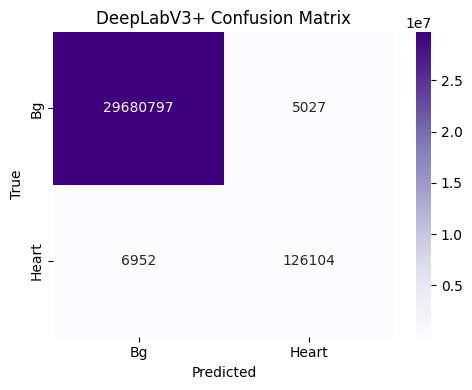

In [ ]:
deeplabv3_results, deeplabv3_preds = evaluate_model(deeplabv3_model, X_test, y_test)
print("=== DeepLabV3+ Results ===")
for k, v in deeplabv3_results.items():
    if k != 'cm':
        print(f"  {k:10s}: {v:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(deeplabv3_results['cm'], annot=True, fmt='d', cmap='Purples',
            xticklabels=['Bg','Heart'], yticklabels=['Bg','Heart'])
plt.title('DeepLabV3+ Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Visualise DeepLabV3+ Predictions

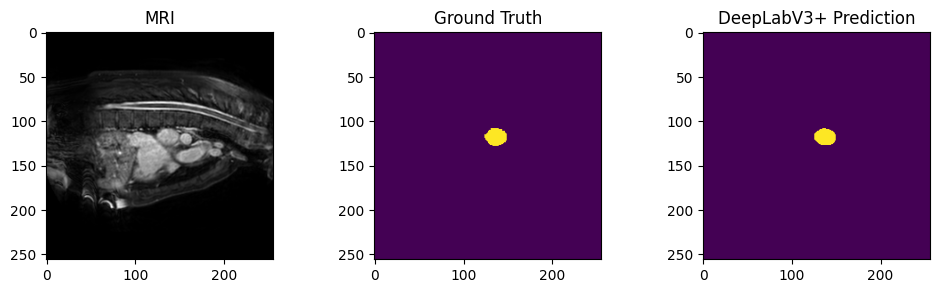

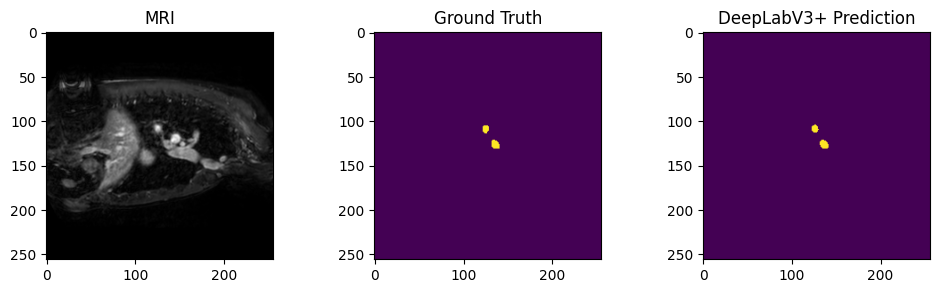

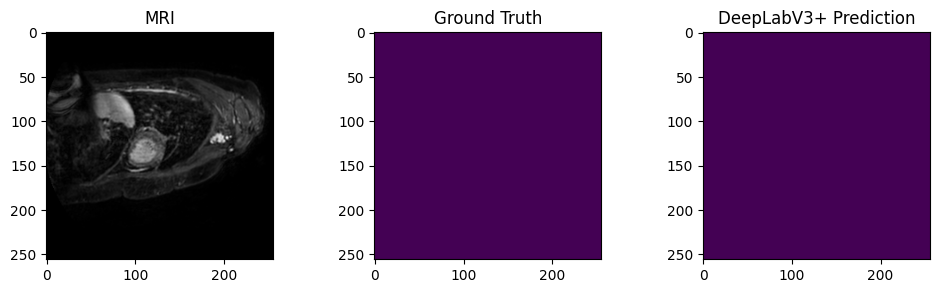

In [ ]:
for i in range(3):
    idx = np.random.randint(0, len(X_test))
    plt.figure(figsize=(10, 3))
    plt.subplot(1,3,1); plt.imshow(X_test[idx].squeeze(), cmap='gray');      plt.title('MRI')
    plt.subplot(1,3,2); plt.imshow(y_test[idx].squeeze());                   plt.title('Ground Truth')
    plt.subplot(1,3,3); plt.imshow(deeplabv3_preds[idx].squeeze());          plt.title('DeepLabV3+ Prediction')
    plt.tight_layout(); plt.show()

In [ ]:
import numpy as np

# Select a random index for demonstration, similar to visualization cells
idx = np.random.randint(0, len(X_test))

y_true = y_test[idx]
y_pred = deeplabv3_preds[idx] # Corrected: Use deeplabv3_preds for the predicted mask

# Ensure y_pred is binary, as dice_coef expects binary masks for accurate calculation
y_pred_binary = (y_pred > 0.5).astype(np.float32) # Assuming a threshold of 0.5 for binarization

intersection = np.sum(y_true * y_pred_binary)
dice = (2. * intersection) / (np.sum(y_true) + np.sum(y_pred_binary) + 1e-8) # Added epsilon for stability

print(f"Dice score for image at index {idx}: {dice:.4f}")

Dice score for image at index 120: 0.9895


---
## 13. 📊 Model Comparison — Bar Graph
Side-by-side comparison of all four models across **Dice Score, IoU, Accuracy, Precision, Recall, and F1 Score**.

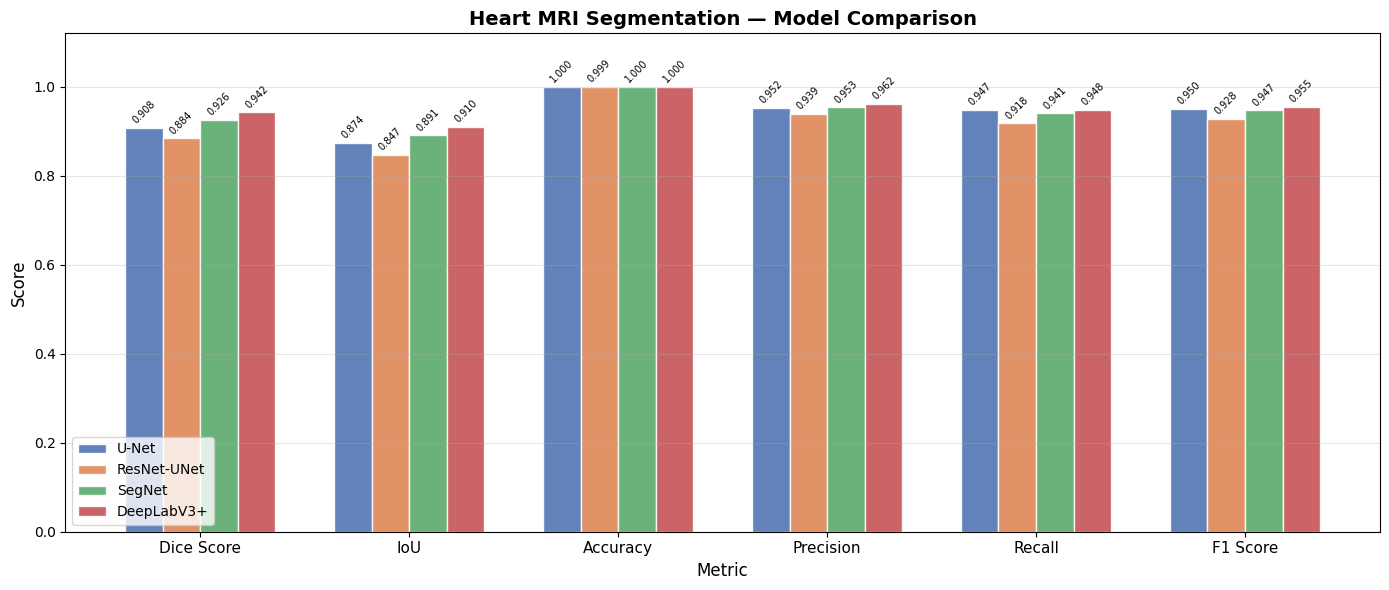

Saved: model_comparison_bar.png


/tmp/ipykernel_4110/1192023065.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=10, fontsize=10)
/tmp/ipykernel_4110/1192023065.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=10, fontsize=10)


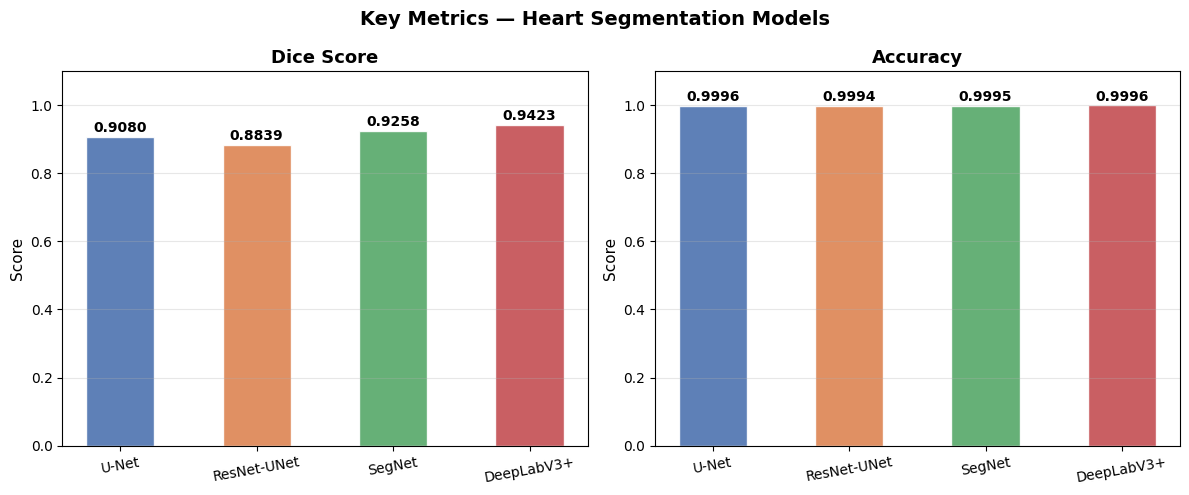

Saved: dice_accuracy_comparison.png


In [ ]:
# ── Collect all results ─────────────────────────────────────────────────────
all_results = {
    'U-Net':          unet_results,
    'ResNet-UNet':    resnet_results,
    'SegNet':         segnet_results,
    'DeepLabV3+':     deeplabv3_results,
}

model_names = list(all_results.keys())
metrics     = ['dice', 'iou', 'accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Dice Score', 'IoU', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
colors      = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']   # one colour per model

# ── 1. Group Bar Chart ───────────────────────────────────────────────────────
x = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, res) in enumerate(all_results.items()):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Heart MRI Segmentation — Model Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison_bar.png")

# ── 2. Dice & Accuracy Side-by-Side Highlight ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, title in zip(axes, ['dice', 'accuracy'], ['Dice Score', 'Accuracy']):
    vals = [all_results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, alpha=0.9, edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(model_names, rotation=10, fontsize=10)

plt.suptitle('Key Metrics — Heart Segmentation Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dice_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dice_accuracy_comparison.png")

## 14. Summary Table & Best Model

In [ ]:
import pandas as pd

rows = []
for name, res in all_results.items():
    rows.append({
        'Model':     name,
        'Dice':      f"{res['dice']:.4f}",
        'IoU':       f"{res['iou']:.4f}",
        'Accuracy':  f"{res['accuracy']:.4f}",
        'Precision': f"{res['precision']:.4f}",
        'Recall':    f"{res['recall']:.4f}",
        'F1':        f"{res['f1']:.4f}",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# Best model by Dice
best = max(all_results, key=lambda m: all_results[m]['dice'])
print(f"\n🏆 Best model by Dice Score: {best}  ({all_results[best]['dice']:.4f})")

best_acc = max(all_results, key=lambda m: all_results[m]['accuracy'])
print(f"🏆 Best model by Accuracy  : {best_acc}  ({all_results[best_acc]['accuracy']:.4f})")

      Model   Dice    IoU Accuracy Precision Recall     F1
      U-Net 0.9080 0.8744   0.9996    0.9523 0.9475 0.9499
ResNet-UNet 0.8839 0.8466   0.9994    0.9395 0.9176 0.9284
     SegNet 0.9258 0.8906   0.9995    0.9535 0.9405 0.9470
 DeepLabV3+ 0.9423 0.9099   0.9996    0.9617 0.9478 0.9547

🏆 Best model by Dice Score: DeepLabV3+  (0.9423)
🏆 Best model by Accuracy  : DeepLabV3+  (0.9996)


## 15. Save All Models

In [ ]:
unet_model.save('unet_heart.keras')
resnet_model.save('resnet_unet_heart.keras')
segnet_model.save('segnet_heart.keras')
deeplabv3_model.save('deeplabv3plus_heart.keras')
print("All models saved!")

All models saved!


## 16. Download Comparison Charts

In [ ]:
from google.colab import files
files.download('model_comparison_bar.png')
files.download('dice_accuracy_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>